# Aufgabenblatt 3

*Grundlagen der Visualisierung, Sommersemester 2026*

In diesem Aufgabenblatt lernen Sie die Aufgaben-Abstraktion und die Wahl verschiedener Visueller Kanäle.

**Softwarebibliotheken.**
Zum Visualisieren der Daten ziehen wir `matplotlib` und aus `matplotlib` `pyplot` heran ([Dokumentation](https://matplotlib.org/3.3.4/api/_as_gen/matplotlib.pyplot.html#module-matplotlib.pyplot)).
Im Laufe der Übungen werden wir `numpy` ([Dokumentation](https://numpy.org/doc/1.19/reference/index.html)) verwenden, um komplexere Berechnungen auf Vektoren und Matrizen durchzuführen.
`pandas` ([Dokumentation](https://pandas.pydata.org/pandas-docs/version/1.1/reference/index.html)) ist eine Bibliothek zum Erzeugen von `DataFrame`s, Tabellenstrukturen, mit denen man einfach auch zeilen- und spaltenweise Operationen durchführen kann.


## Aufgabe 1

In dieser Aufgabe üben Sie Aufgaben-Abstraktion am Beispiel des Mensaspeiseplans, den Sie bereits aus dem vorigen Aufgabenblatt kennen.



In [1]:
import pandas as pd

mensa = pd.read_csv('./data_vaihingen.zip')
mensa = mensa.drop(columns=['location', 'allergens', 'price_guest', 'co2_100g', 'kj_100g', 'kj_portion', 'kcal_100g', 'fat_100g', 'sfat_100g', 'sfat_portion', 'carbs_100g', 'sugar_100g', 'protein_100g', 'salt_100g'])
mensa.date = pd.to_datetime(mensa.date)
mensa

,date,category,title,price_student,price_per_100_g,icons,veg,co2_portion,kcal_portion,fat_portion,carbs_portion,sugar_portion,protein_portion,salt_portion
0,2023-01-09,VORSPEISE,Broccolisuppe,0.99,False,vegetarisch,vegetarian,186.9,100.0,6.1,7.1,2.5,3.1,0.6
1,2023-01-09,VEGANER RENNER,Penne mit Champignons und Cocktailtomaten,2.99,False,"vegan,veganer renner",vegan,391.0,489.0,12.1,75.2,6.4,17.4,2.0
2,2023-01-09,HAUPTGERICHT,Mini-Frühlingsrollen mit fruchtiger Currysauce...,4.90,False,vegetarisch,vegetarian,810.4,795.0,34.0,106.6,18.0,11.8,3.0
3,2023-01-09,HAUPTGERICHT,"Paniertes Schweineschnitzel mit Rahmsauce ,Pre...",5.20,False,schwein,nonveg,1285.7,898.0,35.9,98.0,19.8,43.5,6.7
4,2023-01-09,AKTION,Burger Bar,1.10,True,rind/schwein,nonveg,410.1,999.9,60.9,175.7,37.2,54.4,10.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5296,2024-05-03,BEILAGE,Vollkornreis,0.99,False,vegan,vegan,212.4,253.0,2.0,51.8,0.4,5.6,0.5
5297,2024-05-03,SALAT,Beilagensalat,0.99,False,vegan,vegan,22.7,10.0,0.1,1.1,0.9,0.8,0.1
5298,2024-05-03,DESSERT,Mandarinenquark,1.19,False,vegetarisch,vegetarian,627.4,281.0,4.9,45.1,45.1,12.0,0.2
5299,2024-05-03,DESSERT,Karamellpudding,1.19,False,vegetarisch,vegetarian,436.0,277.0,11.8,38.0,30.0,5.4,0.5


Suchen Sie sich eines der folgenden Szenarien aus:

- Studierende möchten etwas über die Preisgestaltung der Mensa lernen
- Ernährungswissenschaftlern möchten etwas über die Gesundheit und Nahrhaftigkeit des Angebots lernen und berichten
- Umweltbeauftragter möchten wissen ob die Mensa umweltfreundlich ist und ob sie sich in dieser Hinsicht verbessert, und die Ergebnisse als Flugblatt verteilen




Abbildung 1 zeigt die ersten Schichten des Nested Model, um zu veranschaulichen in welchem Stadium des Design-Prozesses wir uns befinden.
Mit der Wahl der Benutzendengruppe haben wir unsere *Domäne* bestimmt.
Das *Was?*, also die Daten-Abstraktion, haben wir im vorigen Blatt erledigt.
Nun können wir also mit der Aufgaben-Abstraktion das *Warum?* charakterisieren.


<figure>
    <img src="./nested-model.png" width="200">
    <figcaption><i>Abbildung 1.</i> Die ersten Schichten des Nested Model nach Munzner.</figcaption>
</figure>

Für das Szenario Ihrer Wahl beschreiben Sie nun **drei Aufgaben**.
Benutzen Sie **Handlungs-/Ziel-Paare** (Action-/Target Pairs).
Beschreiben Sie konkret, was das für Ihr Szenario mit dem gegebenen Datensatz bedeutet.
Sie sollten in der Lage sein, Ihre Überlegungen zu erklären und begründen.

Abbildung 2 zeigt die Möglichkeiten für Handlungen und Ziele in abstrakter Form.
Listen sie alle zutreffenden Handlungen und Ziele zu jeder Aufgabe auf.
Geben Sie an ob Daten transformiert werden müssen.

<figure>
    <img src="./task-abstraction.png" width="600">
    <figcaption>
        <i>Abbildung 2.</i>
        Die verschiedenen Aspekte der Aufgaben-Abstraktion.
        Handlungen gibt es auf drei Ebenen (Analysieren/Analyze, Suchen/Search, Abfragen/Query) von eher abstrakt bis konkreter.
    </figcaption>
</figure>

**TODO:**
Aufgabe 1: Wie teuer sind die verschiedenen Kategorien?
Action: Discover
Target: Distribution (One Attribute)
Was kostet ein Hauptgericht oder Dessert im Durchschnitt? Man schaut an, wie die Preise innerhalb jeder Kategorie streuen.
Transformation nötig: Ja, Preise nach Kategorie gruppieren und Durchschnitt/Streuung berechnen.

Aufgabe 2: Bekommt man für mehr Geld auch mehr Kalorien?
Action: Compare 
Target: Correlation
Lohnt sich ein teures Gericht hinsichtlich der Kalorien? Dazu vergleicht man Preis und Kalorien miteinander und schaut, ob ein Zusammenhang besteht.
Transformation nötig: Man braucht einen Graphen mit dem Preis des Gerichts auf der einen Achse und den Kalorien des Gerichts auf der anderen Achse

Aufgabe 3: Sind die Preise im Laufe der Zeit gestiegen?
Action: Discover
Target: Trends
Hat die Mensa die Preise zwischen 2023 und 2024 erhöht? Man schaut wie sich der Durchschnittspreis Monat für Monat entwickelt hat.
Transformation nötig: Ja, Datum auf Monate aggregieren, dann Mittelwert des Preises pro Monat berechnen.

## Aufgabe 2

In den folgenden zwei Aufgaben geht es nun um Markierungen und Kanäle *(marks and channels).*
Im Folgenden sehen Sie zwei Plots.
Schauen Sie sich die Plots genau an und beantworten Sie jeweils folgende Fragen:

1. Welche Datenattribute werden hier grundsätzlich visualisiert?
   Auf welchen Skalen *(scales of measurement)* sind diese anzufinden?
2. Welche Markierungen und Kanäle werden für die Datenattribute jeweils verwendet?
3. Sind die Markierungen und Kanäle für die Datentypen jeweils sinnvoll gewählt?
   Wenn nicht, welche Wahl hätten Sie getroffen?


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Datensatz noch einmal komplett einlesen
mensa = pd.read_csv('./data_vaihingen.zip')
mensa['date'] = pd.to_datetime(mensa['date'])

# Top 10 Desserts, die es am häufigsten gibt, betrachten
dessert = mensa[mensa["category"]=="DESSERT"]
top_10 = dessert["title"].value_counts().head(10).index.tolist()
dessert_t10 = dessert[dessert['title'].isin(top_10)]
#dessert_t10

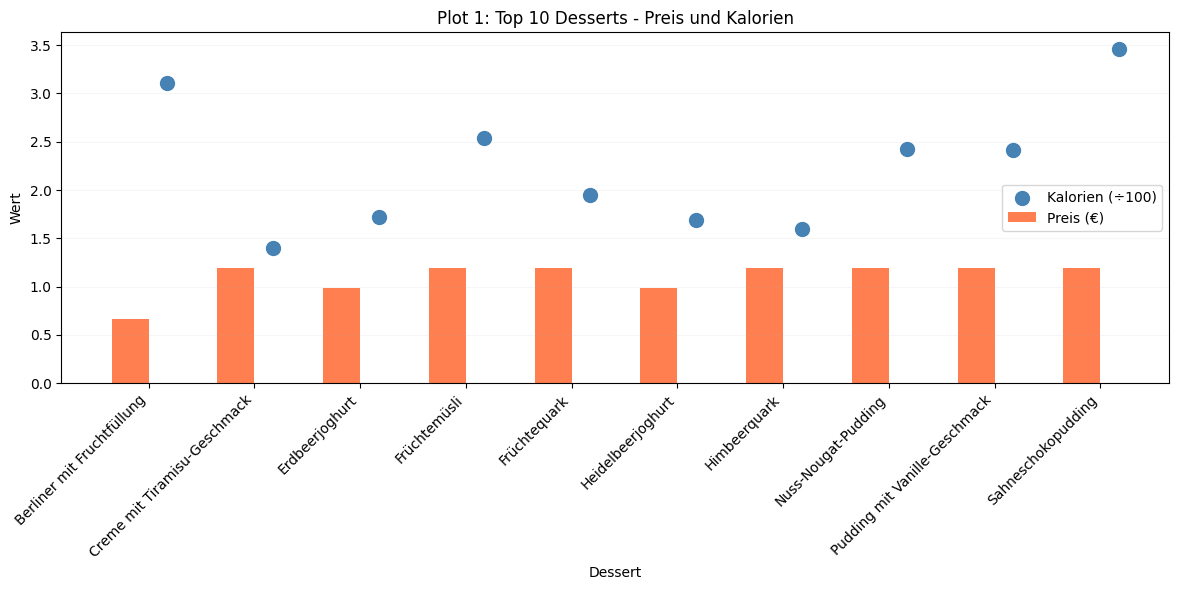

In [14]:
# Plot 1
dessert_agg = dessert_t10.groupby('title').agg({
    'price_student': 'mean',
    'kcal_portion': 'mean'
})


dessert_agg['kcal_scaled'] = dessert_agg['kcal_portion'] / 100  # Skalierung

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(dessert_agg))
width = 0.35

# Balken für Preis
bars1 = ax.bar([i - width/2 for i in x], dessert_agg['price_student'], 
               width, label='Preis (€)', color='coral')

# PUNKTE für Kalorien (statt Balken)
ax.scatter([i + width/2 for i in x], dessert_agg['kcal_scaled'], 
           label='Kalorien (÷100)', color='steelblue', s=100, zorder=3)

ax.set_xlabel('Dessert')
ax.set_ylabel('Wert')
ax.set_title('Plot 1: Top 10 Desserts - Preis und Kalorien')
ax.set_xticks(x)
ax.set_xticklabels(dessert_agg.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.1)
plt.tight_layout()
plt.show()

**TODO:** 
Plot 1: 

1. Gezeigt werden Dessertname (nominal), Preis in € (metrisch) und Kalorien (metrisch).
2. Der Dessertname bestimmt die Position auf der x-Achse. Der Preis wird als Balken dargestellt, die Höhe zeigt den Wert. Die Kalorien werden als Punkte dargestellt, deren Position auf der y-Achse den Wert zeigt. Beide Attribute werden zusätzlich durch Farbe unterschieden.
3. Nicht ideal. Balken und Punkte teilen sich dieselbe y-Achse, aber Kalorien wurden durch 100 geteilt damit sie passen. Das ist verwirrend. Besser wäre ein Scatterplot mit Preis auf der x-Achse und Kalorien auf der y-Achse, oder zwei separate Diagramme.

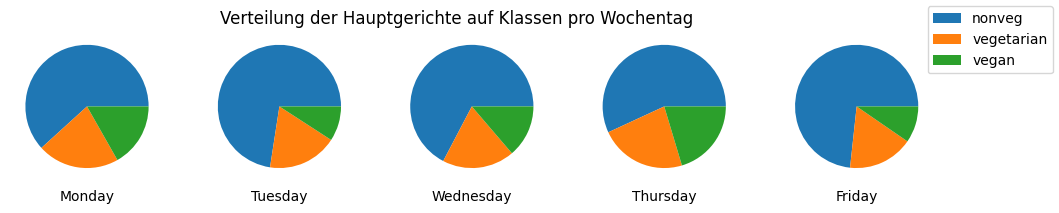

In [97]:
# Plot 2
fig, axs = plt.subplots(1, 5, figsize=(12,2))

#axs
mensa['dow'] = [ d.strftime('%A') for d in mensa['date'] ]
dows = mensa['dow'].unique()

for ax, dow in zip(axs, dows):
    # Achsen und Beschriftung verstecken
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())
    for side in ['top','left','right','bottom']:
        ax.spines[side].set_visible(False)

    data_for_weekday = mensa[(mensa['dow'] == dow) & (mensa['category'] == 'HAUPTGERICHT')]['veg'].value_counts()
    ax.pie(data_for_weekday, labels=list(data_for_weekday.keys()), textprops=dict(size=0, color='white'))
    ax.set_xlabel(dow)


handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.suptitle('Verteilung der Hauptgerichte auf Klassen pro Wochentag')

plt.show()

**TODO:** 
Plot 2:

1. Gezeigt werden Wochentag (nominal), Ernährungsklasse nonveg/vegetarisch/vegan (nominal) und der jeweilige Anteil pro Tag (metrisch).
2. Jedes Tortendiagramm steht für einen Wochentag. Die Ernährungsklassen werden durch Farbe und Kreissegmente dargestellt, der Anteil durch den Winkel des Segments.
3. Nicht ideal. Winkel sind schwer zu vergleichen, besonders über fünf Diagramme hinweg. Besser wäre ein gestapeltes Balkendiagramm, weil man Balkenhöhen viel leichter vergleichen kann.

## Aufgabe 3

**a)** Implementieren Sie jetzt mit dem vollen Mensadatensatz (wird am Anfang von Aufgabe 2 nochmal in die Variable `mensa` geladen) folgende Visualisierung:
Ein **Scatterplot** bildet auf der **x-Achse** den Preis pro Portion (€), auf der **y-Achse** den Proteingehalt pro Portion (g) ab.
Es sollen **kreisförmige Markierungen** verwendet werden.
Deren **Fläche** soll den Nährwert in kcal *pro Portion* abbilden.
Über die **Farbe** der Markierungen soll abgebildet werden, ob das Gericht vegan, vegetarisch oder mit Fleisch ist.
Es sollen **nur Hauptgerichte** visualisiert werden.

---
¹ <small>Für Datenitems, bei denen der Preis pro 100g angegeben ist, müssen Sie das Gewicht der Portion erst berechnen (z.B. über die Spalten für CO₂ pro Portion und pro 100g), um daraus dann den Preis pro Portion zu extrapolieren.</small>  

In [ ]:
# TODO: Implementierung hier

In der Vorlesung haben Sie zu der Kombination von visuellen Markierungen und Kanälen etwas über die **Trennbarkeit** und **Unterscheidbarkeit** gelernt.
Beantworten Sie zu der Kombination der hier implementierten Markierungen und Kanäle, wie trennbar die einzelnen Kombinationspaare (Preis gegen Proteingehalt, Preis gegen Kalorien, Proteingehalt gegen Kalorien) jeweils sind.
Gibt es Interferenzen, und wie beeinflussen die die Unterscheidbarkeit?
Was könnte man anpassen, um dieses Problem zumindest teilweise zu lösen?

**TODO:** *Ihre Antwort hier.*

**b)** Verbessern Sie nun Ihre Implementierung um folgende Punkte:

1. Setzen Sie Ihre Lösung für das oben gefundene Interferenzproblem um.
   Machen Sie sich gegebenenfalls Gedanken, wie und wo Sie die Aufteilungen durchführen wollen.

2. Menschen unterschätzen im Schnitt die Fläche von Kreisen.
   Hier kann man statt dem *mathematical scaling*
   <center>
   $\mathrm{Datenwert} \mapsto \mathrm{Skalierungskonstante}\cdot\sqrt{\mathrm{Datenwert}}$  
   </center>
   
   ein *perceptual scaling* durchführen.
   Dabei nutzt man einen Exponent von $0.5716$ (statt $0.5$ für die Wurzel) für das Mapping² von Datenwert auf Radius:
   <center>
   $\mathrm{Datenwert} \mapsto \mathrm{Skalierungskonstante}\cdot\mathrm{Datenwert}^{0.5716}$  
   </center>

3. Eventuell sind im Scatterplot einige *Outlier,* die die Skalierung beeinflussen und den Rest der Daten schlechter lesbar machen.
   Bestimmen Sie für die quantitativen Variablen jeweils den Mittelwert und die Standardabweichung.
   Entfernen Sie alle Datenpunkte, bei denen der Wert einer Variablen mehr als zwei Standardabweichungen vom Mittelwert entfernt ist.

---
² <small>Nach Flannery (1971). Siehe z.B. Slocum et al.: *Thematic Cartography* (3. Auflage), S. 344ﬀ. Pearson Ltd, 2014.</small>  

In [1]:
# TODO: Implementierung hier